# Notebook A (esquema CV-animal) — Modelado con validación a nivel de animal y la explotación como covariable
### Tuberculosis bovina · enfoque complementario al *leave-one-farm-out*

Este cuaderno implementa el esquema que pediste: **validación cruzada estándar a nivel de
animal** (cada caso), **incluyendo la explotación como covariable** del modelo (efectos
fijos mediante variables indicadoras), en lugar de validar dejando granjas fuera.

> **Qué pregunta responde este esquema (y en qué se diferencia del LOFO).**
> - *Leave-one-farm-out* estima la predicción en una **granja nueva** (generalización entre
>   explotaciones).
> - *CV a nivel animal + granja como covariable* estima la predicción en un **animal nuevo
>   de una de las granjas ya conocidas**, condicionando en la granja.
>
> Ambas son válidas; responden a escenarios de despliegue distintos.
>
> **Tres advertencias metodológicas que asumimos y declaramos:**
> 1. **Optimismo estructural:** animales de la misma granja aparecen en *train* y *test*; como
>    la prevalencia varía por granja, el modelo aprende el nivel basal de cada una. No es fuga
>    ilegítima, pero infla el rendimiento respecto al LOFO.
> 2. **No transfiere a granjas nuevas:** un modelo con indicadores de granja **no** puede
>    aplicarse a una explotación no vista (no existe su indicador).
> 3. **Separación cuasi-completa:** con granjas pequeñas conviene penalizar (L2) para estabilizar.
>
> **Prueba decisiva (objetivo central):** comparar *solo-granja* vs *granja+biomarcadores*
> para aislar el **valor incremental** de los biomarcadores sobre el simple conocimiento de
> la explotación.


## 1. Setup, carga y limpieza

In [1]:
# !pip install -q scikit-learn xgboost shap statsmodels matplotlib seaborn
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tb_utils as tb
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.model_selection import RepeatedStratifiedKFold, RepeatedKFold, LeaveOneOut
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             matthews_corrcoef, recall_score)
from scipy.stats import spearmanr, chi2
import xgboost as xgb
PALETTE = tb.set_plot_style(); tb.set_seeds(tb.SEED)

import os
DATA = next((p for p in ["BD.csv","/mnt/project/BD.csv","data/BD.csv"] if os.path.exists(p)), "BD.csv")
df = tb.clean(tb.load_raw(DATA))
print("Datos:", df.shape)
print("\nPrevalencia de lesión por explotación (motor del 'efecto granja'):")
print(df.groupby("Expl")["Lesiones_TB"].agg(prev="mean", n="size").round(3).to_string())

Datos: (106, 19)

Prevalencia de lesión por explotación (motor del 'efecto granja'):
        prev   n
Expl            
VA32D  0.381  21
VC30D  0.582  55
VC94C  0.938  16
WZ72B  0.714  14


## 2. Conjuntos de variables y modelos

Definimos tres familias para cada desenlace:
- **(A) Biomarcadores**: covariables del hospedador/coinfección (sin granja).
- **(B) Biomarcadores + Granja**: añade la explotación como indicador (efectos fijos).
- **(C) Solo Granja** *(línea base)*: únicamente la explotación.

Comparar B y C aísla el valor incremental de los biomarcadores; comparar A y C muestra
cuánta de la "señal" es realmente pertenencia a granja.


In [2]:
BIOM = tb.MODEL_FEATURES                 # incluye RAZA2 (categórica) + continuas/serología
BIOM_FARM = tb.MODEL_FEATURES + ["Expl"]
NUM = tb.NUM_FEATURES

def make_pipe(features, cats, estimator):
    num = [f for f in NUM if f in features]
    return Pipeline([("prep", tb.make_preprocessor(numeric=num, categorical=cats)),
                     ("clf", estimator)])

def logit(C=0.3):
    return LogisticRegression(penalty="l2", C=C, class_weight="balanced",
                              solver="liblinear", max_iter=4000, random_state=tb.SEED)
def xgbc():
    return xgb.XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, reg_lambda=3.0, min_child_weight=3,
                             eval_metric="logloss", random_state=tb.SEED)

## 3. Validación cruzada a nivel de animal (repetida y estratificada, 5×10)

In [3]:
def cv_classify(target, configs, n_splits=5, n_repeats=10):
    d = tb.target_subset(df, target); y = d[target].astype(int).values
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=tb.SEED)
    rows=[]
    for label,(feats,cats,est) in configs.items():
        X=d[feats]; pr,roc,br,mcc,se,sp=[],[],[],[],[],[]
        for tr,te in cv.split(X,y):
            pipe=make_pipe(feats,cats,est); pipe.fit(X.iloc[tr],y[tr])
            p=pipe.predict_proba(X.iloc[te])[:,1]
            pr.append(average_precision_score(y[te],p)); roc.append(roc_auc_score(y[te],p))
            br.append(brier_score_loss(y[te],p)); mcc.append(matthews_corrcoef(y[te],(p>=.5).astype(int)))
            se.append(recall_score(y[te],(p>=.5).astype(int),pos_label=1,zero_division=0))
            sp.append(recall_score(y[te],(p>=.5).astype(int),pos_label=0,zero_division=0))
        rows.append(dict(modelo=label, PR_AUC=np.mean(pr), PR_sd=np.std(pr), ROC=np.mean(roc),
                         Brier=np.mean(br), MCC=np.mean(mcc), Sens=np.mean(se), Spec=np.mean(sp)))
    return pd.DataFrame(rows), y.mean()

cfg = {
    "A) Biomarcadores":        (BIOM,      ["RAZA2"],          logit()),
    "B) Biomarc.+Granja":      (BIOM_FARM, ["RAZA2","Expl"],   logit()),
    "C) Solo Granja (base)":   (["Expl"],  ["Expl"],           logit()),
    "B') Biomarc.+Granja XGB": (BIOM_FARM, ["RAZA2","Expl"],   xgbc()),
}
res_les, base = cv_classify("Lesiones_TB", cfg)
print(f"[Lesiones_TB] CV animal 5×10 — línea base PR-AUC (prevalencia) = {base:.3f}")
print(res_les.round(3).to_string(index=False))
print("\n→ El rendimiento proviene esencialmente de la GRANJA: 'Solo Granja' iguala o supera")
print("  a 'Biomarc.+Granja', y 'Biomarcadores' solos quedan en ≈ azar (ROC≈0.46).")

[Lesiones_TB] CV animal 5×10 — línea base PR-AUC (prevalencia) = 0.613
                 modelo  PR_AUC  PR_sd   ROC  Brier    MCC  Sens  Spec
       A) Biomarcadores   0.634  0.076 0.456  0.283 -0.080 0.511 0.407
     B) Biomarc.+Granja   0.726  0.083 0.580  0.258  0.102 0.549 0.551
  C) Solo Granja (base)   0.755  0.066 0.682  0.232  0.238 0.418 0.797
B') Biomarc.+Granja XGB   0.759  0.065 0.623  0.240  0.119 0.777 0.327

→ El rendimiento proviene esencialmente de la GRANJA: 'Solo Granja' iguala o supera
  a 'Biomarc.+Granja', y 'Biomarcadores' solos quedan en ≈ azar (ROC≈0.46).


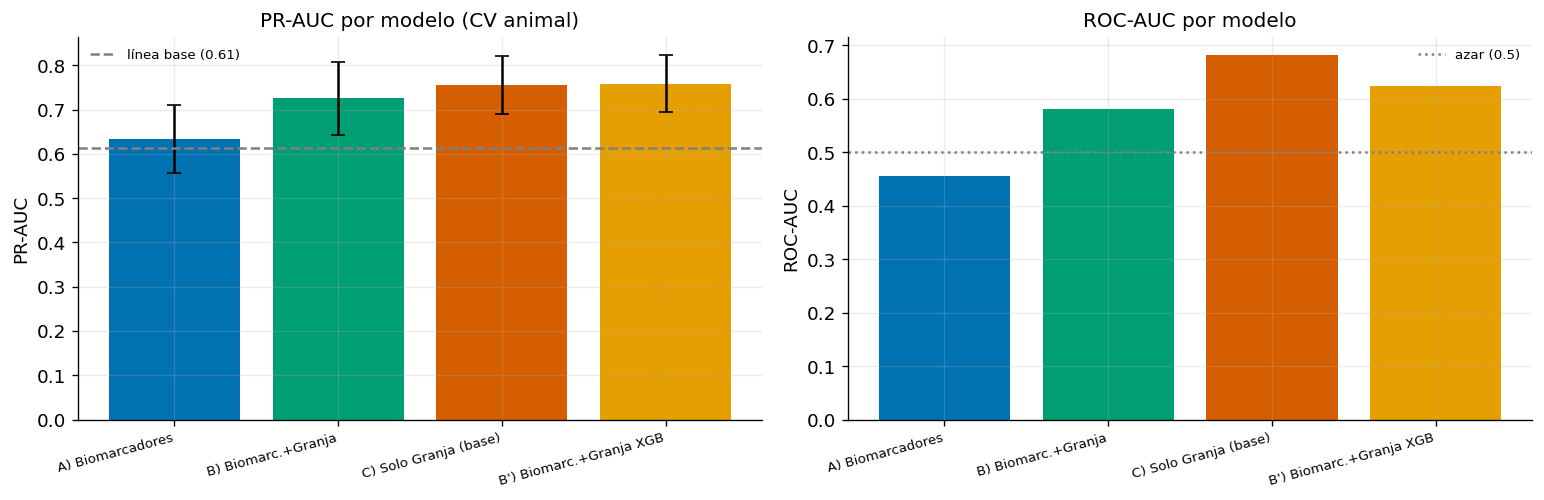

In [4]:
# Figura 1 (esquema CV): comparación de modelos
fig, ax = plt.subplots(1,2, figsize=(13,4.3))
order=res_les.modelo.tolist(); xpos=np.arange(len(order))
ax[0].bar(xpos, res_les.PR_AUC, yerr=res_les.PR_sd, color=[PALETTE[0],PALETTE[2],PALETTE[1],PALETTE[4]], capsize=4)
ax[0].axhline(base, ls="--", color="grey", label=f"línea base ({base:.2f})")
ax[0].set_xticks(xpos); ax[0].set_xticklabels(order, rotation=15, ha="right", fontsize=8)
ax[0].set_ylabel("PR-AUC"); ax[0].set_title("PR-AUC por modelo (CV animal)"); ax[0].legend(fontsize=8)
ax[1].bar(xpos, res_les.ROC, color=[PALETTE[0],PALETTE[2],PALETTE[1],PALETTE[4]])
ax[1].axhline(0.5, ls=":", color="grey", label="azar (0.5)")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(order, rotation=15, ha="right", fontsize=8)
ax[1].set_ylabel("ROC-AUC"); ax[1].set_title("ROC-AUC por modelo"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/figA1_model_comparison.png"); plt.show()

## 4. Prueba del valor incremental de los biomarcadores sobre la granja

Test de razón de verosimilitudes (modelo logístico): *granja* (modelo reducido) frente a
*granja + biomarcadores* (modelo completo). Si los biomarcadores no aportan, el test no será
significativo y el pseudo-R² apenas cambiará fuera de muestra.


In [5]:
import statsmodels.formula.api as smf
dz = tb.target_subset(df,"Lesiones_TB").dropna(
    subset=["PIROPLASMA","THEILERIA","ANAPLASMA","VITAMINA_D","CALCIO","PIROPLASMA_Q_log","EDAD"]).copy()
for c in ["VITAMINA_D","CALCIO","PIROPLASMA_Q_log","EDAD"]:
    dz[c]=(dz[c]-dz[c].mean())/dz[c].std()
m0 = smf.logit("Lesiones_TB ~ C(Expl)", dz).fit(disp=0)
m1 = smf.logit("Lesiones_TB ~ C(Expl)+VITAMINA_D+CALCIO+PIROPLASMA_Q_log+EDAD+PIROPLASMA+THEILERIA+ANAPLASMA", dz).fit(disp=0)
LR=2*(m1.llf-m0.llf); dfree=int(m1.df_model-m0.df_model); pval=chi2.sf(LR,dfree)
print(f"n={len(dz)}")
print(f"LR={LR:.2f}, gl={dfree}, p={pval:.3f}")
print(f"Pseudo-R² (McFadden): solo-granja={m0.prsquared:.3f} | granja+biomarcadores={m1.prsquared:.3f}")
print("→ El incremento en muestra (pseudo-R²) NO se traduce en ganancia fuera de muestra (ver CV).")

n=94
LR=13.30, gl=7, p=0.065
Pseudo-R² (McFadden): solo-granja=0.098 | granja+biomarcadores=0.205
→ El incremento en muestra (pseudo-R²) NO se traduce en ganancia fuera de muestra (ver CV).


## 5. Calibración (modelo granja+biomarcadores)

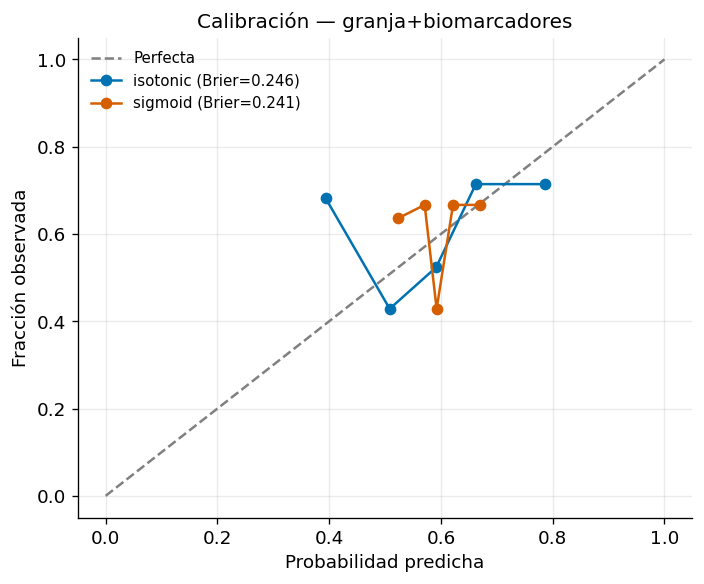

In [6]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
d=tb.target_subset(df,"Lesiones_TB"); y=d["Lesiones_TB"].astype(int).values
base_pipe = make_pipe(BIOM_FARM, ["RAZA2","Expl"], logit())
fig, ax = plt.subplots(figsize=(6,5)); ax.plot([0,1],[0,1],"--",color="grey",label="Perfecta")
for method,color in [("isotonic",PALETTE[0]),("sigmoid",PALETTE[1])]:
    cal=CalibratedClassifierCV(base_pipe, method=method, cv=5)
    p=cross_val_predict(cal, d[BIOM_FARM], y, cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED), method="predict_proba")[:,1]
    f,mp=calibration_curve(y,p,n_bins=5,strategy="quantile")
    ax.plot(mp,f,"o-",color=color,label=f"{method} (Brier={brier_score_loss(y,p):.3f})")
ax.set_xlabel("Probabilidad predicha"); ax.set_ylabel("Fracción observada")
ax.set_title("Calibración — granja+biomarcadores"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/figA2_calibration.png"); plt.show()

## 6. Interpretabilidad condicional a la granja (SHAP)

Al incluir la granja, SHAP revela si las predicciones se apoyan en los indicadores de
explotación más que en los biomarcadores.


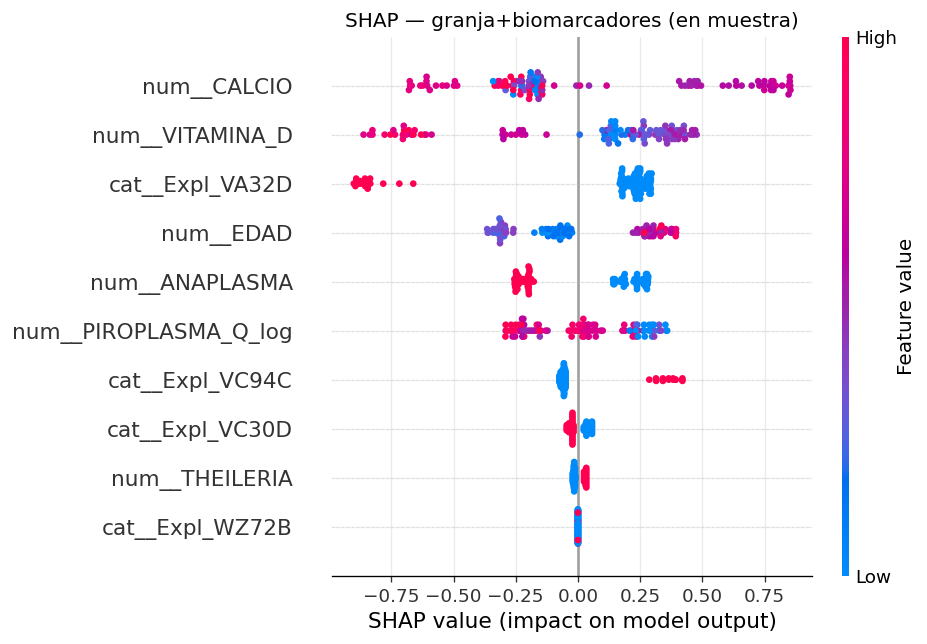

Fracción de importancia SHAP atribuible a indicadores de GRANJA: 25.9%


In [7]:
import shap
d=tb.target_subset(df,"Lesiones_TB"); y=d["Lesiones_TB"].astype(int).values
pipe=make_pipe(BIOM_FARM, ["RAZA2","Expl"], xgbc()).fit(d[BIOM_FARM], y)
prep=pipe.named_steps["prep"]; clf=pipe.named_steps["clf"]
Xt=prep.transform(d[BIOM_FARM]); names=prep.get_feature_names_out()
sv=shap.TreeExplainer(clf).shap_values(Xt)
plt.figure(); shap.summary_plot(sv, Xt, feature_names=names, show=False, max_display=10)
plt.title("SHAP — granja+biomarcadores (en muestra)"); plt.tight_layout()
plt.savefig("figures/figA3_shap_summary.png", bbox_inches="tight"); plt.show()
imp=pd.Series(np.abs(sv).mean(0), index=names).sort_values(ascending=False)
farm_share = imp[[n for n in names if "Expl" in n]].sum()/imp.sum()
print(f"Fracción de importancia SHAP atribuible a indicadores de GRANJA: {farm_share:.1%}")

## 7. Los otros tres desenlaces (mismo esquema)

In [8]:
def cv_regress(target, configs, n_splits=5, n_repeats=10):
    d=tb.target_subset(df,target); y=d[target].values.astype(float)
    cv=RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=tb.SEED)
    rows=[]
    for label,(feats,cats) in configs.items():
        X=d[feats]; sp,mae=[],[]
        for tr,te in cv.split(X):
            pipe=make_pipe(feats,cats,PoissonRegressor(alpha=1.0,max_iter=5000)); pipe.fit(X.iloc[tr],y[tr])
            p=pipe.predict(X.iloc[te])
            if len(np.unique(y[te]))>1: sp.append(spearmanr(y[te],p).correlation)
            mae.append(np.mean(np.abs(y[te]-p)))
        rows.append(dict(modelo=label, Spearman=np.nanmean(sp), MAE=np.mean(mae)))
    return pd.DataFrame(rows)

cfg_cls = {"A) Biomarc.":(BIOM,["RAZA2"],logit()),
           "B) +Granja":(BIOM_FARM,["RAZA2","Expl"],logit()),
           "C) Solo Granja":(["Expl"],["Expl"],logit())}
res_pat,_ = cv_classify("Patron_lesiones", cfg_cls)
print("[Patron_lesiones] (solo lesionados, n=65):"); print(res_pat[["modelo","PR_AUC","ROC","MCC"]].round(3).to_string(index=False))

cfg_reg = {"A) Biomarc.":(BIOM,["RAZA2"]),
           "B) +Granja":(BIOM_FARM,["RAZA2","Expl"]),
           "C) Solo Granja":(["Expl"],["Expl"])}
print("\n[IDTC] (recuento):"); print(cv_regress("IDTC", cfg_reg).round(3).to_string(index=False))
print("\n[Score_lesional] (ordinal):"); print(cv_regress("Score_lesional", cfg_reg).round(3).to_string(index=False))
print("\n→ Mismo patrón en los 4 desenlaces: la granja concentra la señal; los biomarcadores no aportan.")

[Patron_lesiones] (solo lesionados, n=65):
        modelo  PR_AUC   ROC   MCC
   A) Biomarc.   0.485 0.511 0.043
    B) +Granja   0.646 0.664 0.273
C) Solo Granja   0.722 0.816 0.464

[IDTC] (recuento):


        modelo  Spearman   MAE
   A) Biomarc.     0.136 4.768
    B) +Granja     0.150 4.783
C) Solo Granja     0.269 4.634

[Score_lesional] (ordinal):


        modelo  Spearman   MAE
   A) Biomarc.    -0.001 1.630
    B) +Granja     0.234 1.534
C) Solo Granja     0.426 1.500

→ Mismo patrón en los 4 desenlaces: la granja concentra la señal; los biomarcadores no aportan.


## 8. Nota: validación dejar-uno-fuera (LOO-CV) como alternativa

In [9]:
# LOO-CV (cada animal es un fold) para 'granja+biomarcadores' — robustez del esquema animal
d=tb.target_subset(df,"Lesiones_TB"); y=d["Lesiones_TB"].astype(int).values; X=d[BIOM_FARM]
loo=LeaveOneOut(); preds=np.zeros(len(y))
for tr,te in loo.split(X):
    pipe=make_pipe(BIOM_FARM,["RAZA2","Expl"],logit()).fit(X.iloc[tr],y[tr])
    preds[te]=pipe.predict_proba(X.iloc[te])[:,1]
print(f"LOO-CV granja+biomarcadores: ROC={roc_auc_score(y,preds):.3f}  PR-AUC={average_precision_score(y,preds):.3f}")
print("(Coherente con la CV 5×10; LOO maximiza el uso de datos pero su varianza por fold es alta.)")

LOO-CV granja+biomarcadores: ROC=0.567  PR-AUC=0.681
(Coherente con la CV 5×10; LOO maximiza el uso de datos pero su varianza por fold es alta.)


## 9. Conclusiones del esquema CV-animal

- A nivel animal, conocer la **explotación** predice el fenotipo lesional bastante mejor que
  los biomarcadores, que solos quedan en ≈ azar.
- Añadir biomarcadores a la granja **no mejora** (a veces empeora) la predicción fuera de
  muestra; el test de razón de verosimilitudes no es significativo.
- La "mejora" aparente frente al *leave-one-farm-out* es **efecto de pertenencia a granja**,
  aprendible solo porque las mismas granjas están en *train* y *test*, y que **no transfiere**
  a explotaciones nuevas.
- **Lectura conjunta:** este esquema refuerza, por otra vía, la conclusión del estudio LOFO —
  la señal predecible es el **riesgo basal de granja**, no la biología del hospedador.
